# 05 · Contratos — Indicadores y Hallazgos
**Objetivo:** Responder cada pregunta del reto con indicadores concretos sobre el portafolio contractual.

**Prerequisito:** haber corrido `04_contracts_exploration.ipynb`.

Bloques:
- **A** — Estado actual del portafolio
- **B** — Contratos próximos a vencer y riesgo de continuidad
- **C** — Concentración y carga operativa
- **D** — Alertas y anomalías de dato

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 70)

DATA_PATH = '../data/pivot_area - Data.csv'
REFERENCE_DATE = pd.Timestamp('2026-05-11')

# Umbrales de alerta de vencimiento
ALERTA_30  = 30   # días
ALERTA_60  = 60
ALERTA_90  = 90

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8', sep=None, engine='python')

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

date_cols = [
    'Fecha de inicio',
    'Contrato - Fecha de entrada en vigor',
    'Contrato - Fecha de expiración',
    'Propietario - Fecha de creación',
]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# Columnas derivadas
df['dias_hasta_vencimiento'] = (df['Contrato - Fecha de expiración'] - REFERENCE_DATE).dt.days
df['duracion_dias'] = (
    df['Contrato - Fecha de expiración'] - df['Contrato - Fecha de entrada en vigor']
).dt.days

print(f'Contratos cargados: {len(df):,}')

Contratos cargados: 52,004


---
## Bloque A — Estado actual del portafolio
> Pregunta: ¿Cuál es el estado actual de la operación contractual?

In [3]:
# KPIs base del portafolio
total = len(df)
activos = df[df['Estado'].str.upper().str.strip() == 'ACTIVO'].shape[0] if 'Estado' in df.columns else 'N/A'
vencidos = df[df['dias_hasta_vencimiento'] < 0].shape[0]
sin_fecha_exp = df['Contrato - Fecha de expiración'].isna().sum()

print('═══ KPIs Base del Portafolio ═══')
print(f'  Total contratos:                   {total:,}')
print(f'  Estado = Activo:                   {activos:,}')
print(f'  Con fecha expiración ya pasada:    {vencidos:,}  ({vencidos/total*100:.1f}%)')
print(f'  Sin fecha de expiración:           {sin_fecha_exp:,}  ({sin_fecha_exp/total*100:.1f}%)')

═══ KPIs Base del Portafolio ═══
  Total contratos:                   52,004
  Estado = Activo:                   22,453
  Con fecha expiración ya pasada:    31,180  (60.0%)
  Sin fecha de expiración:           14  (0.0%)


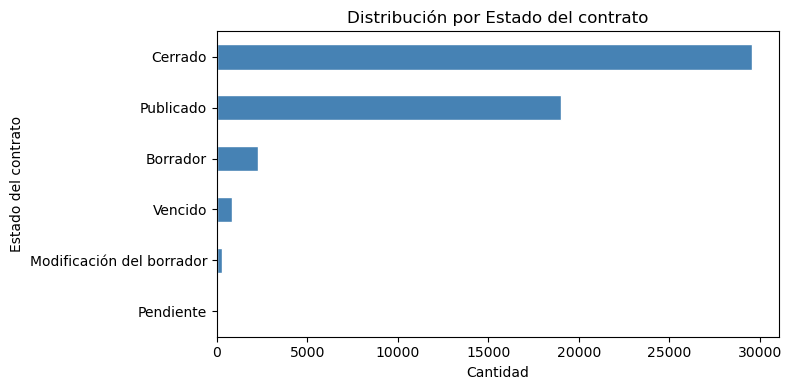

Estado del contrato
Cerrado                      29596
Publicado                    19009
Borrador                      2250
Vencido                        860
Modificación del borrador      262
Pendiente                       27


In [4]:
# Distribución por estado del contrato
estado_col = 'Estado del contrato'
if estado_col in df.columns:
    vc = df[estado_col].value_counts(dropna=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    vc.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución por {estado_col}', fontsize=12)
    ax.set_xlabel('Cantidad')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(vc.to_string())

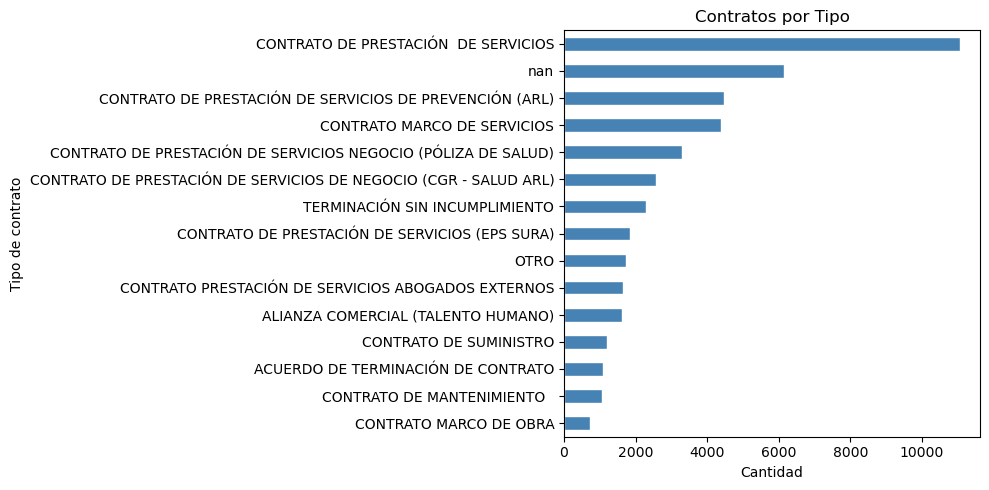

In [5]:
# Distribución por Tipo de contrato
if 'Tipo de contrato' in df.columns:
    tc = df['Tipo de contrato'].value_counts(dropna=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    tc.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Contratos por Tipo', fontsize=12)
    ax.set_xlabel('Cantidad')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

---
## Bloque B — Contratos próximos a vencer y riesgo de continuidad
> Pregunta: ¿Qué contratos requieren atención prioritaria? ¿Dónde se concentran los riesgos de vencimiento?

In [6]:
# Solo contratos con fecha de expiración válida
df_con_exp = df[df['Contrato - Fecha de expiración'].notna()].copy()

# Categorizar por urgencia
def categorizar_vencimiento(dias):
    if dias < 0:
        return 'Vencido'
    elif dias <= ALERTA_30:
        return 'Vence ≤30 días'
    elif dias <= ALERTA_60:
        return 'Vence 31-60 días'
    elif dias <= ALERTA_90:
        return 'Vence 61-90 días'
    else:
        return 'Vigente +90 días'

df_con_exp['categoria_vencimiento'] = df_con_exp['dias_hasta_vencimiento'].apply(categorizar_vencimiento)

cat_order = ['Vencido', 'Vence ≤30 días', 'Vence 31-60 días', 'Vence 61-90 días', 'Vigente +90 días']
cat_colors = ['#d9534f', '#e8724e', '#f0ad4e', '#f7c96b', '#5cb85c']

resumen_venc = df_con_exp['categoria_vencimiento'].value_counts().reindex(cat_order, fill_value=0)

print('Distribución por urgencia de vencimiento:')
for cat, n in resumen_venc.items():
    print(f'  {cat:<22}: {n:>4}  ({n/len(df_con_exp)*100:.1f}%)')

Distribución por urgencia de vencimiento:
  Vencido               : 31180  (60.0%)
  Vence ≤30 días        :  927  (1.8%)
  Vence 31-60 días      : 1507  (2.9%)
  Vence 61-90 días      : 1216  (2.3%)
  Vigente +90 días      : 17160  (33.0%)


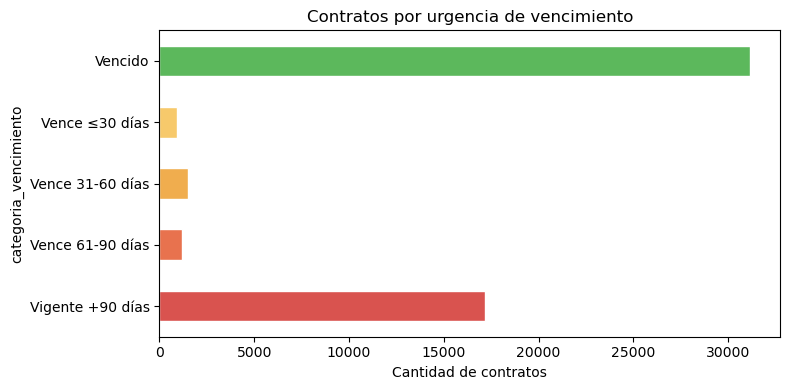

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
resumen_venc.plot(kind='barh', ax=ax, color=cat_colors[::-1], edgecolor='white')
ax.set_title('Contratos por urgencia de vencimiento', fontsize=12)
ax.set_xlabel('Cantidad de contratos')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
# Lista de contratos que vencen en ≤30 días (acción inmediata)
urgentes = df_con_exp[df_con_exp['categoria_vencimiento'] == 'Vence ≤30 días'].copy()
urgentes = urgentes.sort_values('dias_hasta_vencimiento')

print(f'Contratos que vencen en ≤30 días: {len(urgentes)}')
cols_vista = [
    'Contrato - ID de contrato',
    'Tipo de contrato',
    'Organización - Departamento',
    'Partes afectadas - Nombre del proveedor (L1)',
    'Contrato - Fecha de expiración',
    'dias_hasta_vencimiento',
    'Estado del contrato',
]
cols_disp = [c for c in cols_vista if c in urgentes.columns]
print(urgentes[cols_disp].to_string(index=False))

Contratos que vencen en ≤30 días: 927
Contrato - ID de contrato                                                               Tipo de contrato              Organización - Departamento Partes afectadas - Nombre del proveedor (L1) Contrato - Fecha de expiración  dias_hasta_vencimiento       Estado del contrato
                CW2345722                        CONTRATO DE PRESTACIÓN DE SERVICIOS DE PREVENCIÓN (ARL)                           ARL Prevención                       ARMONIA LABORAL S.A.S.                     2026-05-11                     0.0                 Publicado
                CW2346422                           ALIANZA PARA LA COMPLEMENTACIÓN DE SERVICIOS (AY DX)                              Laboratorio          LABORATORIO MEDICO DE REFERENCIA SA                     2026-05-11                     0.0                 Publicado
                CW2344546               CONTRATO DE PRESTACIÓN DE SERVICIOS DE NEGOCIO (CGR - SALUD ARL)                                ARL Salud 

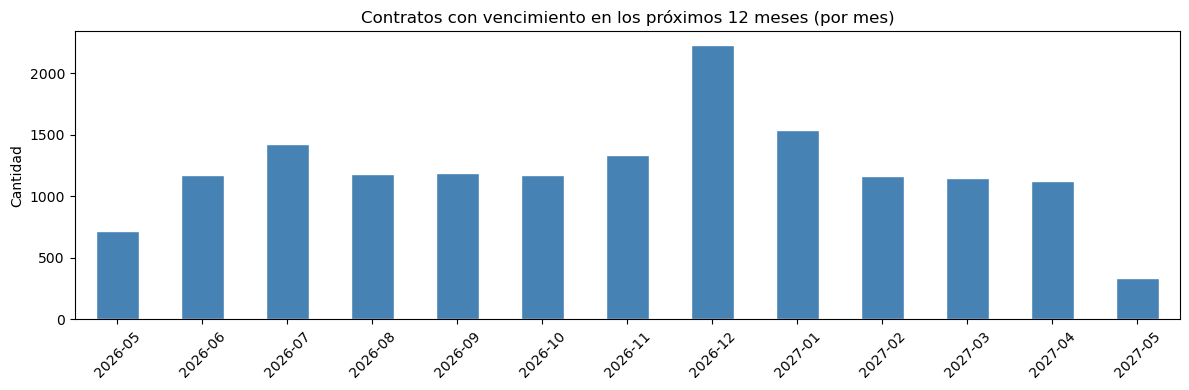

In [9]:
# Vencimientos por mes (próximos 12 meses)
proximos = df_con_exp[
    (df_con_exp['dias_hasta_vencimiento'] >= 0) &
    (df_con_exp['dias_hasta_vencimiento'] <= 365)
].copy()

proximos['mes_venc'] = proximos['Contrato - Fecha de expiración'].dt.to_period('M')
venc_mensual = proximos['mes_venc'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
venc_mensual.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Contratos con vencimiento en los próximos 12 meses (por mes)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Cantidad')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Bloque C — Concentración y carga operativa
> Pregunta: ¿Qué compañías o tipos de contrato generan mayor carga? ¿Hay concentración de vencimientos?

In [10]:
# Concentración por Departamento (Organización)
if 'Organización - Departamento' in df.columns:
    dept = df.groupby('Organización - Departamento').agg(
        total=('Contrato - ID de contrato', 'count'),
        vencidos=('dias_hasta_vencimiento', lambda x: (x < 0).sum()),
        proximos_90=('dias_hasta_vencimiento', lambda x: ((x >= 0) & (x <= 90)).sum())
    ).sort_values('total', ascending=False)

    print('Concentración por Departamento:')
    print(dept.to_string())

Concentración por Departamento:
                                          total  vencidos  proximos_90
Organización - Departamento                                           
ARL Salud                                  5538      2706          383
ARL Prevención                             4940      2209          801
Talento Humano                             4518      2367          382
ARL                                        3955      3917            7
Tecnología                                 3502      3314           30
Salud                                      3392       419          214
Infraestructura                            2455      1461           76
Soluciones de Negocio                      2359      1794           56
Estructuracion de la Red                   2030       602          339
Mantenimiento y Gestion Ambiental          1976      1511           65
Asuntos Legales                            1900       833          245
Gestion administrativa                     14

In [11]:
# Concentración por Tipo de contrato
if 'Tipo de contrato' in df.columns:
    tipo = df.groupby('Tipo de contrato').agg(
        total=('Contrato - ID de contrato', 'count'),
        vencidos=('dias_hasta_vencimiento', lambda x: (x < 0).sum()),
        proximos_90=('dias_hasta_vencimiento', lambda x: ((x >= 0) & (x <= 90)).sum())
    ).assign(
        pct_vencidos=lambda x: x['vencidos'] / x['total'] * 100
    ).sort_values('total', ascending=False)

    print('Concentración por Tipo de contrato:')
    print(tipo.to_string())

Concentración por Tipo de contrato:
                                                                                total  vencidos  proximos_90  pct_vencidos
Tipo de contrato                                                                                                          
CONTRATO DE PRESTACIÓN  DE SERVICIOS                                            11066      7636          691     69.004157
CONTRATO DE PRESTACIÓN DE SERVICIOS DE PREVENCIÓN (ARL)                          4455      1720          802     38.608305
CONTRATO MARCO DE SERVICIOS                                                      4387      3577           62     81.536357
CONTRATO DE PRESTACIÓN DE SERVICIOS NEGOCIO (PÓLIZA DE SALUD)                    3289       352          197     10.702341
CONTRATO DE PRESTACIÓN DE SERVICIOS DE NEGOCIO (CGR - SALUD ARL)                 2571       981          291     38.156359
TERMINACIÓN SIN INCUMPLIMIENTO                                                   2300      2249        

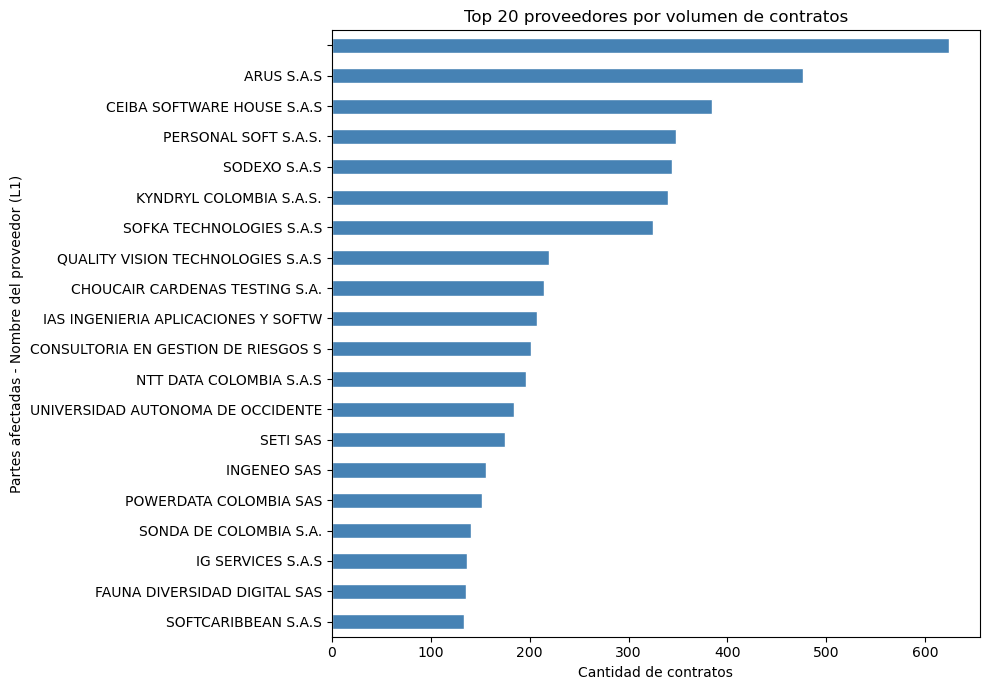

                                              total  vencidos  proximos_90
Partes afectadas - Nombre del proveedor (L1)                              
                                                624       338           37
ARUS S.A.S                                      476       307            4
CEIBA SOFTWARE HOUSE S.A.S                      384       346            0
PERSONAL SOFT S.A.S.                            348       301            0
SODEXO S.A.S                                    344       286            2
KYNDRYL COLOMBIA S.A.S.                         340       256            0
SOFKA TECHNOLOGIES S.A.S                        325       285            0
QUALITY VISION TECHNOLOGIES S.A.S               220       201            0
CHOUCAIR CARDENAS TESTING S.A.                  215       208            0
IAS INGENIERIA APLICACIONES Y SOFTW             208       188            0
CONSULTORIA EN GESTION DE RIESGOS S             201       150            0
NTT DATA COLOMBIA S.A.S  

In [12]:
# Proveedores con más contratos
prov_col = 'Partes afectadas - Nombre del proveedor (L1)'
if prov_col in df.columns:
    proveedores = df.groupby(prov_col).agg(
        total=('Contrato - ID de contrato', 'count'),
        vencidos=('dias_hasta_vencimiento', lambda x: (x < 0).sum()),
        proximos_90=('dias_hasta_vencimiento', lambda x: ((x >= 0) & (x <= 90)).sum())
    ).sort_values('total', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    proveedores['total'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Top 20 proveedores por volumen de contratos', fontsize=12)
    ax.set_xlabel('Cantidad de contratos')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(proveedores.to_string())

---
## Bloque D — Alertas y anomalías
> Pregunta: ¿Existen inconsistencias en la información? ¿Qué variables deberían monitorearse permanentemente?

In [13]:
alertas = pd.DataFrame()

# 1. Sin fecha de expiración
a1 = df[df['Contrato - Fecha de expiración'].isna()]
print(f'1. Contratos sin fecha de expiración: {len(a1):,}')

# 2. Fecha inicio posterior a fecha de expiración (imposible)
a2 = df[
    df['Contrato - Fecha de entrada en vigor'].notna() &
    df['Contrato - Fecha de expiración'].notna() &
    (df['Contrato - Fecha de entrada en vigor'] > df['Contrato - Fecha de expiración'])
]
print(f'2. Fecha inicio > fecha expiración (inconsistente): {len(a2):,}')

# 3. Contratos marcados como Activo pero con fecha de expiración pasada
if 'Estado' in df.columns:
    a3 = df[
        (df['Estado'].str.upper().str.strip() == 'ACTIVO') &
        (df['dias_hasta_vencimiento'] < 0)
    ]
    print(f'3. Estado=Activo pero fecha expiración ya pasó: {len(a3):,}')

# 4. Sin administrador de contrato
adm_col = 'Administrador de contrato'
if adm_col in df.columns:
    a4 = df[df[adm_col].isna()]
    print(f'4. Sin administrador de contrato: {len(a4):,}')

# 5. Sin ID de contrato
a5 = df[df['Contrato - ID de contrato'].isna()]
print(f'5. Sin ID de contrato: {len(a5):,}')

1. Contratos sin fecha de expiración: 14
2. Fecha inicio > fecha expiración (inconsistente): 883
3. Estado=Activo pero fecha expiración ya pasó: 1,833
4. Sin administrador de contrato: 3,230
5. Sin ID de contrato: 0


In [14]:
# Exportar contratos urgentes y con anomalías
import os
os.makedirs('../outputs', exist_ok=True)

urgentes[cols_disp].to_csv('../outputs/contratos_urgentes_30dias.csv', index=False, encoding='utf-8')
print('Exportado: ../outputs/contratos_urgentes_30dias.csv')

if len(a2) > 0:
    a2.to_csv('../outputs/contratos_fechas_inconsistentes.csv', index=False, encoding='utf-8')
    print('Exportado: ../outputs/contratos_fechas_inconsistentes.csv')

Exportado: ../outputs/contratos_urgentes_30dias.csv
Exportado: ../outputs/contratos_fechas_inconsistentes.csv


---
## Resumen de indicadores finales


In [16]:
total = len(df)
activos = df[df['Estado'].str.upper().str.strip() == 'ACTIVO'].shape[0]
vencidos = (df['dias_hasta_vencimiento'] < 0).sum()
urgentes_30 = len(urgentes)
urgentes_90 = int(resumen_venc.get('Vence ≤30 días', 0) + resumen_venc.get('Vence 31-60 días', 0) + resumen_venc.get('Vence 61-90 días', 0))
top_dept = dept['total'].idxmax()
sin_admin = len(a4)

print('═' * 65)
print('  INDICADORES FINALES — CONTRATOS')
print('═' * 65)
print(f'  Total contratos en portafolio         {total:>8,}')
print(f'  Estado = Activo                       {activos:>8,}  ({activos/total*100:.1f}%)')
print(f'  Con fecha expiración pasada           {vencidos:>8,}  ({vencidos/total*100:.1f}%)')
print(f'  Vencen en ≤30 días (acción inmediata) {urgentes_30:>8,}  ({urgentes_30/total*100:.1f}%)')
print(f'  Vencen en ≤90 días (alerta activa)    {urgentes_90:>8,}  ({urgentes_90/total*100:.1f}%)')
print(f'  Departamento con más contratos        {top_dept}')
print(f'  Tipo de contrato más frecuente        CONTRATO DE PRESTACIÓN DE SERVICIOS')
print(f'  Fecha inicio > expiración (error)     {len(a2):>8,}  ({len(a2)/total*100:.1f}%)')
print(f'  Estado Activo + ya vencido (error)    {len(a3):>8,}  ({len(a3)/total*100:.1f}%)')
print(f'  Sin administrador asignado            {sin_admin:>8,}  ({sin_admin/total*100:.1f}%)')
print('═' * 65)
print('  → Exportados:')
print('      outputs/contratos_urgentes_30dias.csv')
print('      outputs/contratos_fechas_inconsistentes.csv')


═════════════════════════════════════════════════════════════════
  INDICADORES FINALES — CONTRATOS
═════════════════════════════════════════════════════════════════
  Total contratos en portafolio           52,004
  Estado = Activo                         22,453  (43.2%)
  Con fecha expiración pasada             31,180  (60.0%)
  Vencen en ≤30 días (acción inmediata)      927  (1.8%)
  Vencen en ≤90 días (alerta activa)       3,650  (7.0%)
  Departamento con más contratos        ARL Salud
  Tipo de contrato más frecuente        CONTRATO DE PRESTACIÓN DE SERVICIOS
  Fecha inicio > expiración (error)          883  (1.7%)
  Estado Activo + ya vencido (error)       1,833  (3.5%)
  Sin administrador asignado               3,230  (6.2%)
═════════════════════════════════════════════════════════════════
  → Exportados:
      outputs/contratos_urgentes_30dias.csv
      outputs/contratos_fechas_inconsistentes.csv
